In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
from IPython.display import display
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR    = CONFIGS['filepaths']['splits']
WEIGHTSDIR   = CONFIGS['filepaths']['weights']
MODELSDIR    = CONFIGS['filepaths']['models']
FIELDVARS    = CONFIGS['experiments']['sr']['runs']['sr_atm']['fieldvars']
SEEDS        = CONFIGS['experiments']['nn']['seeds']
SPLIT        = 'test'
LANDFRAC     = 0.5
SAMPLETHRESH = 50
NCUBES       = [3,4,5,6,7]
PCS          = {
    r'$\mathrm{PC}_1$':{'label':r'$\frac{\partial\mathrm{P}}{\partial\widehat{\mathrm{RH}}} \geq 0$',
           'testvar':'rh','expectedsign':1,'othervars':['thetae','thetaestar']},
    r'$\mathrm{PC}_2$':{'label':r'$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e}} \geq 0$',
           'testvar':'thetae','expectedsign':1,'othervars':['rh','thetaestar']},
    r'$\mathrm{PC}_3$':{'label':r'$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e^*}} \leq 0$',
           'testvar':'thetaestar','expectedsign':-1,'othervars':['rh','thetae']}}
BLPC         = {'label':r'$\frac{\partial\mathrm{P}}{\partial B_L} \geq 0$','testvar':'bl','expectedsign':1,'othervars':['bl']}
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
REGISTRY     = {row['name']:json.loads(row['constants']) for _,row in pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv')).iterrows()}
FIGSDIR      = 'figs'
os.makedirs(FIGSDIR,exist_ok=True)

In [4]:
def hypercube_test(pc,ncubes,regionmask):
    tested   = predictors[pc['testvar']]
    condit   = [predictors[name] for name in pc['othervars']]
    nbins    = ncubes**(2//len(condit))
    binidxs  = [np.clip(np.digitize(values,np.linspace(*np.percentile(values[regionmask],[1,99]),nbins+1))-1,0,nbins-1) for values in condit]
    cubeidxs = np.ravel_multi_index(binidxs,[nbins]*len(condit))
    results  = []
    for cubeidx in range(ncubes**2):
        selected = regionmask&(cubeidxs==cubeidx)
        if selected.sum()<SAMPLETHRESH:
            continue
        testedvalues,tpvalues = tested[selected],tp[selected]
        centered = testedvalues-testedvalues.mean()
        slope    = np.dot(centered,tpvalues)/(np.dot(centered,centered)+1e-12)
        results.append((slope,slope*pc['expectedsign']>=0,testedvalues.mean(),tpvalues.mean(),np.mean(tpvalues==0)))
    return pd.DataFrame(results,columns=['slope','satisfied','meantest','meantp','zerofrac'])

In [5]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    dsig   = ds['dsig'].values
    fields = np.stack([ds[name].transpose('time','lat','lon','sig').values.reshape(-1,dsig.size) for name in FIELDVARS],axis=1)
    bl     = ds['bl'].transpose('time','lat','lon').values.ravel()
    lf     = xr.broadcast(ds['lf'],ds[FIELDVARS[0]].isel(sig=0))[0].transpose('time','lat','lon').values.ravel().astype(np.float64)
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    tp = ds['pr'].transpose('time','lat','lon').values.ravel()
kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds['k'].values)

integrals  = (fields*np.mean(kernels,axis=0)[None,:,:]*dsig[None,None,:]).sum(axis=2)
finite     = np.isfinite(integrals).all(axis=1)&np.isfinite(tp)
predictors = {**dict(zip(FIELDVARS,integrals[finite].T)),'bl':bl[finite]}
lf,tp      = lf[finite],tp[finite]
masks      = {'Land':lf>=LANDFRAC,'Ocean':lf<LANDFRAC,'All':np.ones(len(tp),dtype=bool)}

obsrows = []
for pc in [*PCS.values(),BLPC]:
    for region,mask in masks.items():
        scores = {rf'$n = {n}$':100*hypercube_test(pc,n,mask&np.isfinite(predictors[pc['testvar']]))['satisfied'].mean() for n in NCUBES}
        obsrows.append({'Constraint':pc['label'],'Region':region,**scores,'Average':np.mean(list(scores.values()))})
obsdf   = pd.DataFrame(obsrows)
allcubes = pd.concat([hypercube_test(next(iter(PCS.values())),n,masks['Ocean']) for n in NCUBES],ignore_index=True)

rh,thetae,thetaestar,bl = (predictors[name] for name in ['rh','thetae','thetaestar','bl'])
atm       = REGISTRY['sr_atm_eq']
argument  = thetae-atm['c4']*thetaestar-atm['c5']
rhbranch  = rh>=argument
atmgrad   = {'rh':np.where(rhbranch,3*atm['c3']*rh**2,0.0),
             'thetae':np.where(rhbranch,0.0,3*atm['c3']*argument**2),
             'thetaestar':np.where(rhbranch,0.0,-3*atm['c3']*atm['c4']*argument**2)}
c10,c13   = REGISTRY['sr_all_eq']['c10'],REGISTRY['sr_all_pc_eq']['c13']
gradients = {'SR-ATM':atmgrad,
             'SR-SFC':atmgrad,
             'SR-ALL':{**atmgrad,'thetae':atmgrad['thetae']+(c10-lf)**3},
             'SR-ALL-PC':{**atmgrad,'thetae':atmgrad['thetae']+(c13-lf)**3+(1-c13)**3}}
obs       = obsdf.set_index(['Constraint','Region'])['Average']
regions   = dict(zip(PCS,['Land','All','All']))
blgrad    = 3*(bl+REGISTRY['sr_bl_eq']['c1'])**2
rows      = [{'Model':'IMERG',**{pc['label']:obs[pc['label'],regions[pcname]] for pcname,pc in PCS.items()},BLPC['label']:obs[BLPC['label'],'All']},
             {'Model':'SR-BL',BLPC['label']:100*(blgrad>=0)[np.isfinite(bl)].mean()}]
for model,gradient in gradients.items():
    rows.append({'Model':model,**{pc['label']:100*(gradient[pc['testvar']]*pc['expectedsign']>=0)[masks[regions[pcname]]].mean() for pcname,pc in PCS.items()}})
modeldf   = pd.DataFrame(rows)

In [6]:
display(modeldf.style.hide(axis='index').format('{:.1f}%',subset=modeldf.columns[1:],na_rep='--'))

Model,$\frac{\partial\mathrm{P}}{\partial\widehat{\mathrm{RH}}} \geq 0$,$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e}} \geq 0$,$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e^*}} \leq 0$,$\frac{\partial\mathrm{P}}{\partial B_L} \geq 0$
IMERG,100.0%,94.8%,91.5%,75.6%
SR-BL,--,--,--,100.0%
SR-ATM,100.0%,100.0%,100.0%,--
SR-SFC,100.0%,100.0%,100.0%,--
SR-ALL,100.0%,88.6%,100.0%,--
SR-ALL-PC,100.0%,100.0%,100.0%,--


In [7]:
display(obsdf.style.hide(axis='index').format({**{rf'$n = {n}$':'{:.1f}%' for n in NCUBES},'Average':'{:.1f}%'}))

Constraint,Region,$n = 3$,$n = 4$,$n = 5$,$n = 6$,$n = 7$,Average
$\frac{\partial\mathrm{P}}{\partial\widehat{\mathrm{RH}}} \geq 0$,Land,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
$\frac{\partial\mathrm{P}}{\partial\widehat{\mathrm{RH}}} \geq 0$,Ocean,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
$\frac{\partial\mathrm{P}}{\partial\widehat{\mathrm{RH}}} \geq 0$,All,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e}} \geq 0$,Land,100.0%,93.3%,95.8%,90.9%,95.7%,95.1%
$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e}} \geq 0$,Ocean,100.0%,93.3%,86.4%,81.2%,79.1%,88.0%
$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e}} \geq 0$,All,100.0%,93.3%,95.7%,93.9%,90.9%,94.8%
$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e^*}} \leq 0$,Land,88.9%,93.8%,84.0%,80.6%,79.6%,85.4%
$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e^*}} \leq 0$,Ocean,100.0%,87.5%,88.0%,86.1%,83.7%,89.1%
$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e^*}} \leq 0$,All,100.0%,93.8%,88.0%,86.1%,89.8%,91.5%
$\frac{\partial\mathrm{P}}{\partial B_L} \geq 0$,Land,100.0%,93.8%,64.0%,72.2%,69.4%,79.9%


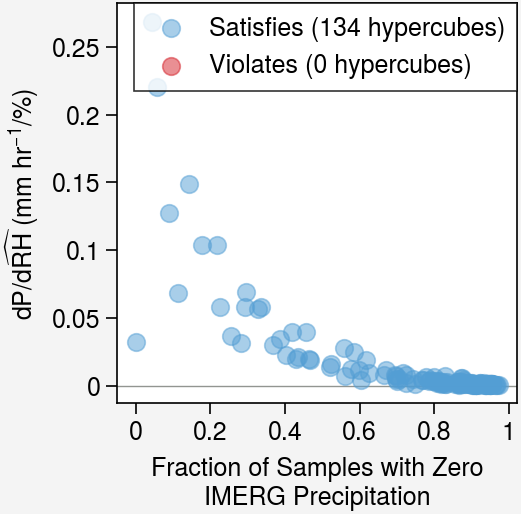

2.71


In [8]:
fig,ax = pplt.subplots(refwidth=2,refheight=2)
ax.format(grid=False,xlabel='Fraction of Samples with Zero\nIMERG Precipitation',xticks=0.2,ylabel='$dP/d\\widehat{RH}$ (mm hr$^{-1}$/%)')
for satisfied,color,label in [(True,'#539ED4','Satisfies'),(False,'#D42028','Violates')]:
    cubes = allcubes[allcubes['satisfied']==satisfied]
    ax.scatter(cubes['zerofrac'],cubes['slope']/STATS['rh_std'],color=color,markersize=40,alpha=0.5,label=f'{label} ({len(cubes)} hypercubes)')
ax.axhline(0,color='gray',linewidth=0.5,zorder=0)
ax.legend(loc='ur',ncols=1)
pplt.show()
fig.save(os.path.join(FIGSDIR,'fig_S2.jpg'))
print(round(fig.get_figwidth(),2))